In [246]:
import pandas as pd
df = pd.read_csv("/content/EmployeeAttrition.csv")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.shape

(1470, 35)

In [247]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [248]:
df.columns[df.nunique()==1]

Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='object')

In [249]:
df.drop(columns=["EmployeeCount","Over18","StandardHours","EmployeeNumber"],inplace=True)
df.shape

(1470, 31)

In [250]:
label = {"Attrition":{"Yes":1,"No":0}}
X.replace(label,inplace=True)

In [251]:
X = df.drop('Attrition', axis=1)
Y = df['Attrition']

In [252]:
df.isnull().sum().sum()

np.int64(0)

In [253]:
X.shape,Y.shape

((1470, 30), (1470,))

In [254]:
label_map = {"BusinessTravel":{"Travel_Rarely":1,"Travel_Frequently":2,"Non-Travel":0}}
X.replace(label_map,inplace=True)

/tmp/ipykernel_1857/2745971885.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.replace(label_map,inplace=True)


In [255]:
X["BusinessTravel"].unique()

array([1, 2, 0])

In [256]:
X_ohe = pd.get_dummies(X)

X_ohe.shape

(1470, 49)

In [257]:
Y.nunique()

2

In [258]:
cont_col = X.columns[X.nunique()>15]

In [259]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X_ohe,Y_ohe,test_size=0.3,random_state=7,stratify=y)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((1029, 49), (441, 49), (1029, 2), (441, 2))

In [260]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[cont_col] = sc.fit_transform(X_train[cont_col])
X_test[cont_col] = sc.transform(X_test[cont_col])

In [261]:
X_train[cont_col].mean()

,0
Age,2.175131e-16
DailyRate,-1.381035e-16
DistanceFromHome,-8.631472e-17
HourlyRate,-2.727545e-16
MonthlyIncome,6.905177e-17
MonthlyRate,1.294721e-16
TotalWorkingYears,8.631472e-17
YearsAtCompany,2.934700e-17
YearsInCurrentRole,8.113583e-17
YearsSinceLastPromotion,7.250436e-17


In [262]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95,random_state=7) #all possible components
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_train_pca.shape, X_test_pca.shape

((1029, 23), (441, 23))

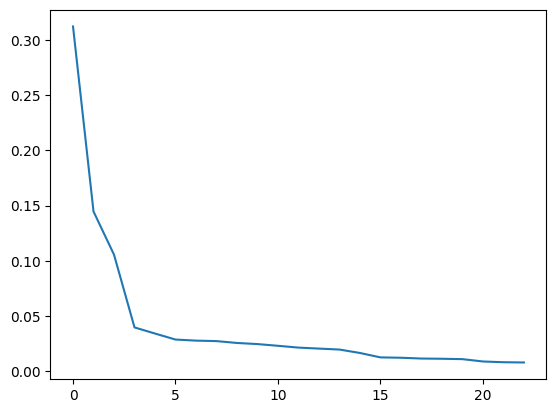

In [263]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)),pca.explained_variance_ratio_)

In [264]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel="rbf",random_state=7)
kpca.fit(X_train)

KernelPCA(kernel='rbf', random_state=7)

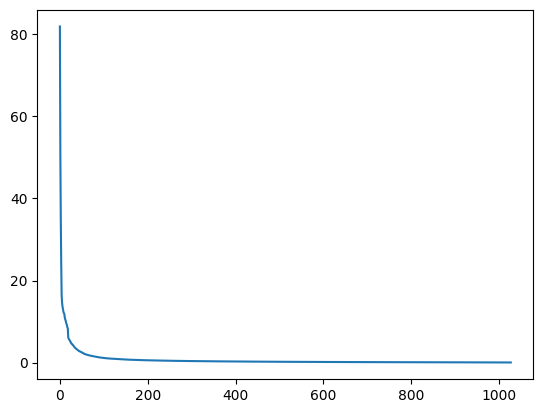

In [265]:
import matplotlib.pyplot as plt
plt.plot(range(len(kpca.eigenvalues_)),kpca.eigenvalues_)

In [266]:
kpca.eigenvalues_.shape

(1028,)

In [267]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
rfe = RFE(LogisticRegression(random_state=7),verbose=2)
rfe.fit_transform(X_train,Y_train['Yes'])
print(rfe.ranking_)

Fitting estimator with 49 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Fitting estimator with 48 features.
Fitting estimator with 47 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 46 features.


...

Fitting estimator with 43 features.
Fitting estimator with 42 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting estimator with 41 features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
[10  1 19  2 26  1 24  1 22  1  1 23 11 25 16  6 18 12 17  1  1  1  1  1
 20  7  1  1 15  1  1 14  1 13  5  1  1  1  1  8  1 21  9  1  3  4  1  1
  1]


In [268]:
for col,rank in zip(X_train.columns,rfe.ranking_):
  print(col,rank)

Age 10
BusinessTravel 1
DailyRate 19
DistanceFromHome 2
Education 26
EnvironmentSatisfaction 1
HourlyRate 24
JobInvolvement 1
JobLevel 22
JobSatisfaction 1
MonthlyIncome 1
MonthlyRate 23
NumCompaniesWorked 11
PercentSalaryHike 25
PerformanceRating 16
RelationshipSatisfaction 6
StockOptionLevel 18
TotalWorkingYears 12
TrainingTimesLastYear 17
WorkLifeBalance 1
YearsAtCompany 1
YearsInCurrentRole 1
YearsSinceLastPromotion 1
YearsWithCurrManager 1
Department_Human Resources 20
Department_Research & Development 7
Department_Sales 1
EducationField_Human Resources 1
EducationField_Life Sciences 15
EducationField_Marketing 1
EducationField_Medical 1
EducationField_Other 14
EducationField_Technical Degree 1
Gender_Female 13
Gender_Male 5
JobRole_Healthcare Representative 1
JobRole_Human Resources 1
JobRole_Laboratory Technician 1
JobRole_Manager 1
JobRole_Manufacturing Director 8
JobRole_Research Director 1
JobRole_Research Scientist 21
JobRole_Sales Executive 9
JobRole_Sales Representative 1


In [274]:
selected_cols = X_train.columns[rfe.ranking_ == 1]
selected_cols

Index(['BusinessTravel', 'EnvironmentSatisfaction', 'JobInvolvement',
       'JobSatisfaction', 'MonthlyIncome', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Technical Degree', 'JobRole_Healthcare Representative',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Research Director',
       'JobRole_Sales Representative', 'MaritalStatus_Single', 'OverTime_No',
       'OverTime_Yes'],
      dtype='object')

In [270]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = "gini",random_state=7,class_weight="balanced")
dt.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=7)

In [271]:
fi = zip(X_train.columns,dt.feature_importances_)
for col,imp in sorted(fi,key=(lambda x:x[1]),reverse=True):
  print(col,imp)

MonthlyIncome 0.08947105457995277
MonthlyRate 0.06983530721989045
DistanceFromHome 0.06814959757424562
PercentSalaryHike 0.06612386783531578
Education 0.05857310529177371
OverTime_No 0.05741843382577042
Age 0.05469269472020156
HourlyRate 0.03937625159599
DailyRate 0.038800453197592594
WorkLifeBalance 0.035433523555063996
YearsSinceLastPromotion 0.03518950206564143
TrainingTimesLastYear 0.033781089442648134
YearsInCurrentRole 0.03017854771522077
EducationField_Medical 0.026530070700239883
MaritalStatus_Single 0.025023229735527296
NumCompaniesWorked 0.024299443617407195
YearsAtCompany 0.024133872698091672
TotalWorkingYears 0.023336434291096247
RelationshipSatisfaction 0.020873683237317413
StockOptionLevel 0.02075270337000327
JobSatisfaction 0.02062230372631859
EducationField_Life Sciences 0.018914958139706763
BusinessTravel 0.016913996287802525
JobLevel 0.0162401497099015
EnvironmentSatisfaction 0.012438130137183671
JobRole_Healthcare Representative 0.011349430617502303
JobRole_Research 

In [272]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion = "entropy",random_state=7,class_weight="balanced")
dt.fit(X_train,Y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       random_state=7)

In [273]:
fi = zip(X_train.columns,dt.feature_importances_)
for col,imp in sorted(fi,key=(lambda x:x[1]),reverse=True):
  print(col,imp)

PercentSalaryHike 0.0809098807522478
YearsInCurrentRole 0.07943767030789707
DailyRate 0.06837665504380723
OverTime_No 0.06829949233173642
DistanceFromHome 0.06420957971003537
MonthlyIncome 0.061481205676671334
Age 0.06112189614136291
Education 0.04670992482449424
StockOptionLevel 0.039347478907744086
MonthlyRate 0.03770481865499861
JobSatisfaction 0.03704078897567877
RelationshipSatisfaction 0.035971980573981814
JobLevel 0.03278387183785708
TrainingTimesLastYear 0.027643540362570065
NumCompaniesWorked 0.025109091611840002
EducationField_Life Sciences 0.02232733992974329
YearsWithCurrManager 0.02133165189094742
HourlyRate 0.019971437907135754
JobRole_Research Director 0.01940780400469827
YearsSinceLastPromotion 0.019403423198887382
TotalWorkingYears 0.018804335925748674
JobRole_Research Scientist 0.016266199419348263
WorkLifeBalance 0.012608493997967015
EnvironmentSatisfaction 0.012543454966270134
YearsAtCompany 0.012496750286567989
JobRole_Sales Executive 0.009276380155257507
JobRole_H